# 공통 준비 (환경 설정 & 유틸 함수)

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# plt.rcParams['font.family'] = 'Malgun Gothic' # For Windows
plt.rcParams['font.family'] = 'AppleGothic' # For MacOS

## 문제 1) 데이터 로드 & 결합 (2022~2024)

요구사항:
1. `2022.csv ~ 2024.csv` 로드 (인코딩 `cp949` 권장)  
2. 세 파일을 **세로 concat** 해서 `df` 생성  
3. `df.shape`, `df.head(3)`, `df.columns` 출력

In [5]:
data_2022 = pd.read_csv('data/2022.csv', encoding='cp949')
data_2023 = pd.read_csv('data/2023.csv', encoding='cp949')
data_2024 = pd.read_csv('data/2024.csv', encoding='cp949')
dfs = [data_2022, data_2023, data_2024]
df = pd.concat(dfs, axis=0, ignore_index=True)

print("df.shape:", df.shape)
display(df.head(3))
print("columns:", list(df.columns))

df.shape: (213628, 21)


/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_5197/3636460353.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2024 = pd.read_csv('data/2024.csv', encoding='cp949')


,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한 개업공인중개사 시군구명
0,2022,11260,중랑구,10100,면목동,1.0,대지,173.0,164.0,은하빌라,...,16000,50.35,28.50,3.0,NaN,NaN,1996.0,연립다세대,중개거래,서울 마포구
1,2022,11215,광진구,10500,자양동,1.0,대지,860.0,0.0,테라팰리스건대2차,...,105000,75.03,0.00,17.0,NaN,NaN,2018.0,아파트,중개거래,서울 강남구
2,2022,11680,강남구,10300,개포동,1.0,대지,1165.0,16.0,칠성빌라나동,...,69000,50.28,41.77,1.0,NaN,NaN,1989.0,연립다세대,중개거래,서울 강남구


columns: ['접수연도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분', '지번구분명', '본번', '부번', '건물명', '계약일', '물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)', '층', '권리구분', '취소일', '건축년도', '건물용도', '신고구분', '신고한 개업공인중개사 시군구명']


## 문제 2) 시각화 전에 5분 점검 루틴 (정답 예시)

아래는 **답안 예시 형태**입니다.  
여러분들은 마크다운 셀로 1~2줄씩 쓰면 됩니다.

체크 항목:
1) 데이터 크기  
2) 타입(dtypes)  
3) 결측치 Top 5  
4) 범주형 값 분포(예: `건물용도`, `신고구분`)  
5) 단위 확인(만원, ㎡ 등)

In [6]:
# 1) 데이터 크기
print("행/열:", df.shape)

# 2) 타입 확인
display(df.info())

# 3) 결측치 TOP 5
missing_top5 = df.isna().mean().sort_values(ascending=False).head(5)
display(missing_top5.to_frame("missing_ratio").style.format({"missing_ratio":"{:.2%}"}))

# 4) 범주형 값 분포 예시
for col in ["건물용도", "신고구분"]:
    if col in df.columns:
        print(f"\n[{col}] value_counts(dropna=False)")
        display(df[col].value_counts(dropna=False).head(10))

# 5) 단위(데이터 사전 느낌)
unit_note = pd.DataFrame({
    "컬럼": ["물건금액(만원)", "건물면적(㎡)", "계약일"],
    "단위/형식": ["만원", "㎡", "YYYYMMDD(정수) -> datetime으로 변환 필요"]
})
display(unit_note)

행/열: (213628, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213628 entries, 0 to 213627
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   접수연도              213628 non-null  int64  
 1   자치구코드             213628 non-null  int64  
 2   자치구명              213627 non-null  object 
 3   법정동코드             213628 non-null  int64  
 4   법정동명              213628 non-null  object 
 5   지번구분              203405 non-null  float64
 6   지번구분명             203405 non-null  object 
 7   본번                203407 non-null  object 
 8   부번                203407 non-null  object 
 9   건물명               203387 non-null  object 
 10  계약일               213628 non-null  int64  
 11  물건금액(만원)          213628 non-null  int64  
 12  건물면적(㎡)           213628 non-null  float64
 13  토지면적(㎡)           208477 non-null  float64
 14  층                 203429 non-null  float64
 15  권리구분              1390 non-null    object 
 16  취소

None

AttributeError: The '.style' accessor requires jinja2

## 문제 3) 날짜/문자열 정리 + 파생 컬럼 만들기

요구사항:
1. `계약일` -> datetime 변환  
2. `계약연`, `계약월`, `계약연월` 생성  
3. 문자열 컬럼 2개 이상 strip (예: `자치구명`, `법정동명`)

In [ ]:
# 1) 계약일 -> datetime
df["계약일_dt"] = pd.to_datetime(df["계약일"].astype(str), format="%Y%m%d", errors="coerce")

# 2) 파생 컬럼 생성
df["계약연"] = df["계약일_dt"].dt.year
df["계약월"] = df["계약일_dt"].dt.month
# Period(M)로 두면 정렬/집계가 편함
df["계약연월"] = df["계약일_dt"].dt.to_period("M")

# 3) 문자열 strip (앞/뒤 공백 제거)
for col in ["자치구명", "법정동명", "건물명", "건물용도", "신고구분"]:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].astype("string").str.strip()

display(df[["계약일", "계약일_dt", "계약연", "계약월", "계약연월"]].head(3))


,계약일,계약일_dt,계약연,계약월,계약연월
0,20230424,2023-04-24,2023,4,2023-04
1,20230216,2023-02-16,2023,2,2023-02
2,20230109,2023-01-09,2023,1,2023-01


## 문제 4) 결측치/중복 처리

**핵심 컬럼**
- `자치구명`, `법정동명`, `건물용도`, `계약일_dt`, `물건금액(만원)`, `건물면적(㎡)`

정답(예시) 전략:
- `물건금액(만원)` 또는 `건물면적(㎡)` 결측은 분석이 불가능하므로 **행 제거**
- `건물명` 결측은 분석 필수는 아니므로 `"Unknown"` 대체(선택)
- 완전 중복행은 `drop_duplicates()`로 제거

근거(왜?)를 마크다운으로 3줄 정도 쓰세요


In [ ]:
# 처리 전 shape
print("before:", df.shape)

core_cols = ["자치구명", "법정동명", "건물용도", "계약일_dt", "물건금액(만원)", "건물면적(㎡)"]
core_cols = [c for c in core_cols if c in df.columns]

# 핵심 컬럼 결측 확인
core_missing = df[core_cols].isna().mean().sort_values(ascending=False)
display(core_missing.to_frame("missing_ratio").style.format({"missing_ratio":"{:.2%}"}))

# (1) 핵심 수치 결측 제거
df_clean = df.copy()
df_clean = df_clean.dropna(subset=["물건금액(만원)", "건물면적(㎡)", "계약일_dt"])

# (2) 선택: 건물명 결측 대체
if "건물명" in df_clean.columns:
    df_clean["건물명"] = df_clean["건물명"].fillna("Unknown")

# (3) 수치형 이상값(면적<=0) 제거(최소한의 안전장치)
df_clean = df_clean[df_clean["건물면적(㎡)"] > 0]

# (4) 완전 중복 제거
dup_cnt = df_clean.duplicated().sum()
print("완전 중복 행 개수:", dup_cnt)
df_clean = df_clean.drop_duplicates()

print("after:", df_clean.shape)


before: (213628, 25)


,missing_ratio
자치구명,0.00%
법정동명,0.00%
건물용도,0.00%
계약일_dt,0.00%
물건금액(만원),0.00%
건물면적(㎡),0.00%


완전 중복 행 개수: 5297
after: (208331, 25)


### (근거 예시 문장)

- `물건금액(만원)`과 `건물면적(㎡)`는 **㎡당 가격**을 만들기 위한 핵심 수치이므로 결측이면 계산이 불가하여 삭제했습니다.  
- `건물명`은 분석의 핵심 질문(거래량/가격 분포/구별 비교)에서는 필수는 아니어서 `"Unknown"`으로 대체했습니다.  
- 완전 중복행은 동일 관측이 반복된 것이므로 `drop_duplicates()`로 제거했습니다.

## 문제 5) 파생 변수 만들기 — ㎡당/평당 가격

- `㎡당_가격(만원) = 물건금액(만원) / 건물면적(㎡)`
- `평당_가격(만원) = ㎡당_가격(만원) * 3.3058`
- `㎡당_가격(만원)` 요약 통계: count/mean/median/min/max

In [ ]:
df_clean["㎡당_가격(만원)"] = df_clean["물건금액(만원)"] / df_clean["건물면적(㎡)"]
df_clean["평당_가격(만원)"] = df_clean["㎡당_가격(만원)"] * 3.3058

summary = df_clean["㎡당_가격(만원)"].agg(["count","mean","median","min","max"])
display(summary.to_frame("value"))

display(df_clean[["물건금액(만원)", "건물면적(㎡)", "㎡당_가격(만원)", "평당_가격(만원)"]].head(3))

,value
count,208331.000000
mean,1121.790415
median,952.094608
min,29.007127
max,9833.585477


,물건금액(만원),건물면적(㎡),㎡당_가격(만원),평당_가격(만원)
0,16000,50.35,317.775571,1050.502483
1,105000,75.03,1399.440224,4626.269492
2,69000,50.28,1372.315036,4536.599045


## 문제 6) 그룹화 & 피벗테이블

(1) 자치구별 거래 건수 TOP 10  
(2) 건물용도별 평균 ㎡당 가격 (내림차순)  
(3) 피벗테이블: index=`자치구명`, columns=`건물용도`, values=`㎡당_가격(만원)`, aggfunc=`mean`

In [ ]:
# (1) 구별 거래량 TOP 10
gu_cnt = df_clean["자치구명"].value_counts().head(10)
display(gu_cnt.to_frame("거래건수"))

# (2) 건물용도별 평균 ㎡당 가격
use_mean_price = (
    df_clean.groupby("건물용도")["㎡당_가격(만원)"]
    .mean()
    .sort_values(ascending=False)
)
display(use_mean_price.to_frame("평균_㎡당가격(만원)").head(20))

# (3) 피벗테이블
pivot_mean = df_clean.pivot_table(
    index="자치구명",
    columns="건물용도",
    values="㎡당_가격(만원)",
    aggfunc="mean",
)

# 결측 채우기(선택): 보기 편하게 0으로
pivot_mean_filled = pivot_mean.fillna(0)

display(pivot_mean_filled.head())
print("pivot shape:", pivot_mean_filled.shape)

,거래건수
자치구명,
강서구,16622
송파구,13211
은평구,11547
강남구,11010
강동구,10655
마포구,10358
구로구,9578
영등포구,9212
양천구,8756


,평균_㎡당가격(만원)
건물용도,
아파트,1461.827979
단독다가구,991.949286
오피스텔,848.682494
연립다세대,823.799079


건물용도,단독다가구,아파트,연립다세대,오피스텔
자치구명,,,,
강남구,1684.172252,2613.497345,1559.268019,1023.955562
강동구,711.058285,1472.882396,893.332778,698.445087
강북구,629.116747,883.265443,516.511731,616.850435
강서구,683.042048,1122.211746,659.169816,783.743818
관악구,640.516593,1014.524076,683.015639,793.422432


pivot shape: (25, 4)


## 문제 7) 시각화 4개 + 해석(각 1~2줄)

> 원칙: **제목/축 라벨/단위**를 넣고, 그래프 아래 1~2줄 해석을 붙입니다.

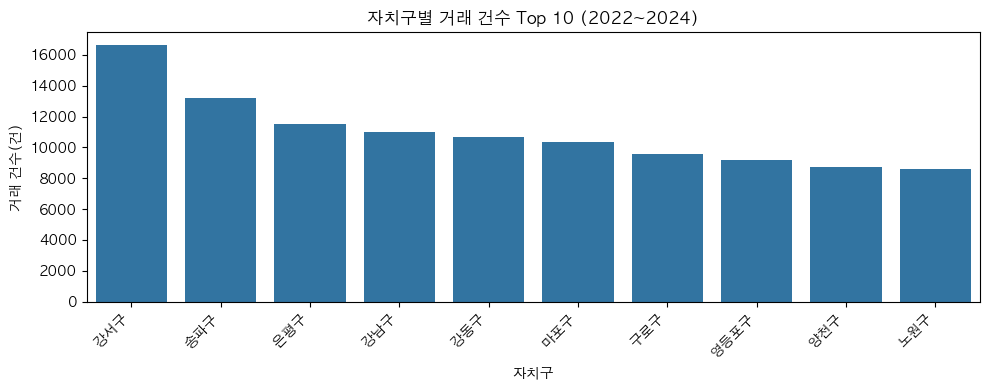

해석 예시: 거래 건수는 '강서구'가 16,622건으로 가장 많습니다. (Top10은 구별 거래량 편차를 빠르게 보여줌)


In [ ]:
# 그래프 1) 자치구별 거래 건수 TOP 10 (막대그래프)
plt.figure(figsize=(10, 4))
order = gu_cnt.sort_values(ascending=False).index
sns.barplot(x=gu_cnt.loc[order].index, y=gu_cnt.loc[order].values, errorbar=None)
plt.title("자치구별 거래 건수 Top 10 (2022~2024)")
plt.xlabel("자치구")
plt.ylabel("거래 건수(건)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_gu = gu_cnt.index[0]
top_cnt = int(gu_cnt.iloc[0])
print(f"해석 예시: 거래 건수는 '{top_gu}'가 {top_cnt:,}건으로 가장 많습니다. (Top10은 구별 거래량 편차를 빠르게 보여줌)")

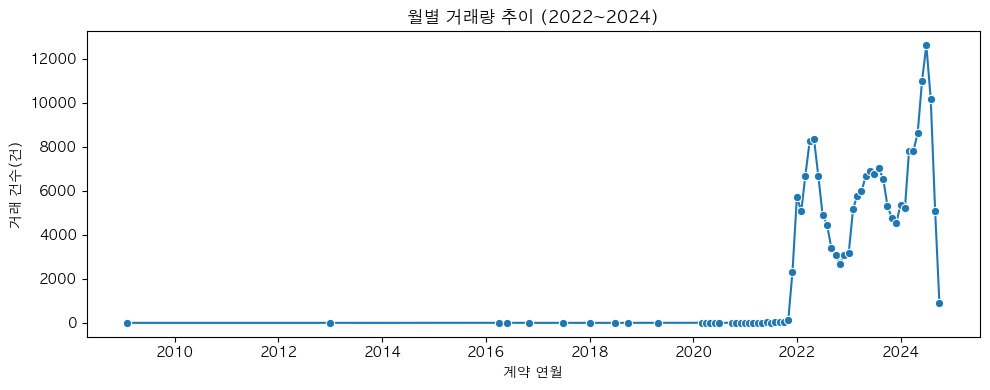

해석 예시: 월별 거래량은 2024-07에 가장 많고, 2009-02에 가장 적습니다. (변동이 큰 달이 있다면 시즌성/정책/금리 등의 추가 확인 포인트)


In [ ]:
# 그래프 2) 월별 거래량 추이 (라인차트)
monthly_cnt = (
    df_clean.groupby("계약연월")
    .size()
    .sort_index()
)

# Period -> Timestamp로 바꿔서 x축 라벨을 자연스럽게
monthly_cnt_ts = monthly_cnt.copy()
monthly_cnt_ts.index = monthly_cnt_ts.index.to_timestamp()

plt.figure(figsize=(10, 4))
sns.lineplot(x=monthly_cnt_ts.index, y=monthly_cnt_ts.values, marker="o")
plt.title("월별 거래량 추이 (2022~2024)")
plt.xlabel("계약 연월")
plt.ylabel("거래 건수(건)")
plt.tight_layout()
plt.show()

max_month = monthly_cnt_ts.idxmax().strftime("%Y-%m")
min_month = monthly_cnt_ts.idxmin().strftime("%Y-%m")
print(f"해석 예시: 월별 거래량은 {max_month}에 가장 많고, {min_month}에 가장 적습니다. (변동이 큰 달이 있다면 시즌성/정책/금리 등의 추가 확인 포인트)")

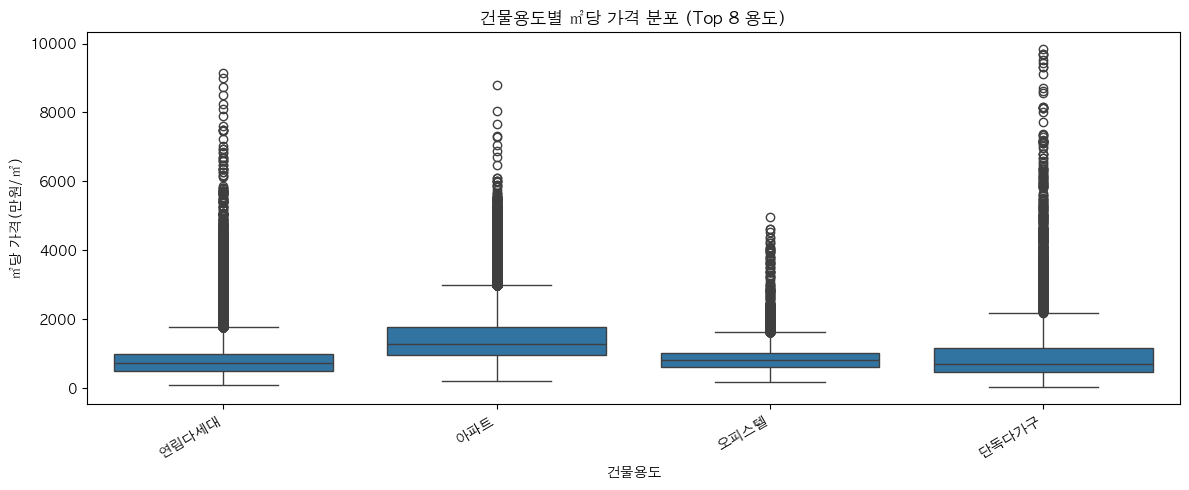

해석 예시: 박스플롯 기준으로 '아파트' 용도가 중앙값(중간 가격)이 상대적으로 높게 나타납니다. (평균만 보면 이상치 영향이 커서 박스플롯이 안전)


In [ ]:
# 그래프 3) 건물용도별 ㎡당 가격 분포 (박스플롯)
# 범주가 너무 많으면 상위 N개만 보이게 제한(예: 거래량 상위 8개 용도)
top_uses = df_clean["건물용도"].value_counts().head(8).index
plot_df = df_clean[df_clean["건물용도"].isin(top_uses)].copy()

plt.figure(figsize=(12, 5))
sns.boxplot(data=plot_df, x="건물용도", y="㎡당_가격(만원)")
plt.title("건물용도별 ㎡당 가격 분포 (Top 8 용도)")
plt.xlabel("건물용도")
plt.ylabel("㎡당 가격(만원/㎡)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 해석용: 용도별 중앙값 비교
med_by_use = plot_df.groupby("건물용도")["㎡당_가격(만원)"].median().sort_values(ascending=False)
best_use = med_by_use.index[0]
print(f"해석 예시: 박스플롯 기준으로 '{best_use}' 용도가 중앙값(중간 가격)이 상대적으로 높게 나타납니다. (평균만 보면 이상치 영향이 커서 박스플롯이 안전)")

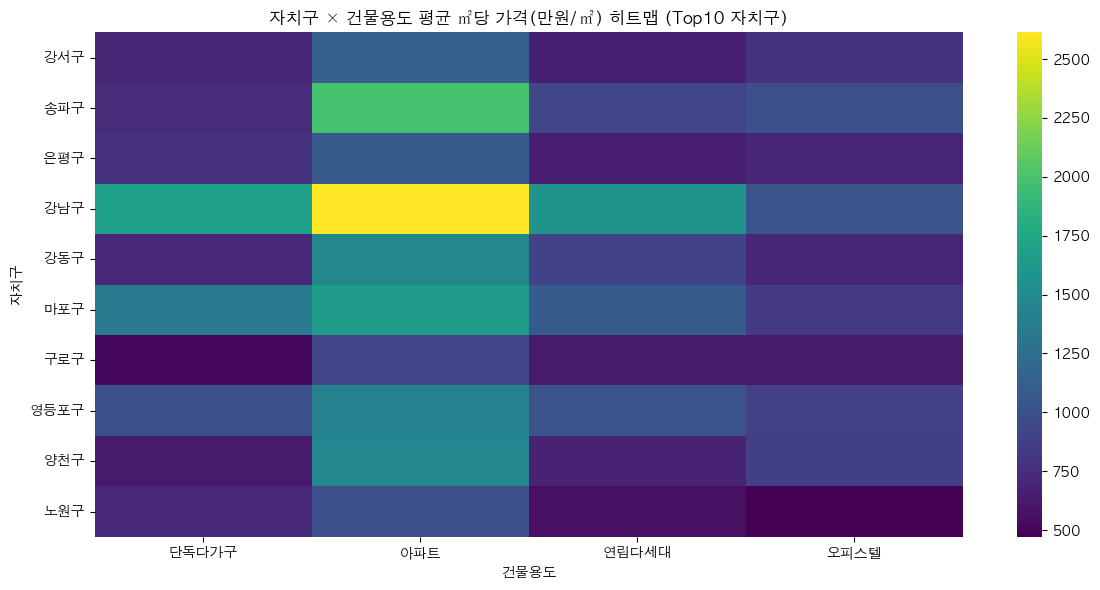

해석 예시: Top10 자치구 내에서 '강남구×아파트' 조합의 평균 ㎡당 가격이 가장 높게 나타납니다(약 2,613 만원/㎡).


In [ ]:
# 그래프 4) 히트맵 (자치구 × 건물용도 평균 ㎡당 가격)
# 자치구가 너무 많으면 Top10 구만 필터
top10_gus = gu_cnt.index
pivot_top10 = pivot_mean.loc[top10_gus].fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_top10, cmap="viridis")  # annot는 너무 빽빽하면 False 권장
plt.title("자치구 × 건물용도 평균 ㎡당 가격(만원/㎡) 히트맵 (Top10 자치구)")
plt.xlabel("건물용도")
plt.ylabel("자치구")
plt.tight_layout()
plt.show()

# 해석용: Top10 구/용도 조합 중 최댓값 찾기
max_pos = np.unravel_index(np.argmax(pivot_top10.values), pivot_top10.shape)
max_gu = pivot_top10.index[max_pos[0]]
max_use = pivot_top10.columns[max_pos[1]]
max_val = pivot_top10.iloc[max_pos]
print(f"해석 예시: Top10 자치구 내에서 '{max_gu}×{max_use}' 조합의 평균 ㎡당 가격이 가장 높게 나타납니다(약 {max_val:,.0f} 만원/㎡).")

## 문제 8) 5문장 결론 + 다음 분석 2가지 (정답 예시)

In [ ]:
# 결론용 요약 숫자 만들기
YEARS = [2022, 2023, 2024]
total_tx = len(df_clean)
years_span = f"{YEARS[0]}~{YEARS[-1]}"
avg_price_sqm = df_clean["㎡당_가격(만원)"].mean()
median_price_sqm = df_clean["㎡당_가격(만원)"].median()

top_gu = df_clean["자치구명"].value_counts().idxmax()
top_gu_cnt = int(df_clean["자치구명"].value_counts().max())

top_use = df_clean["건물용도"].value_counts().idxmax()
top_use_cnt = int(df_clean["건물용도"].value_counts().max())

# 월별 변동
monthly_cnt_ts = (
    df_clean.groupby("계약연월").size().sort_index()
)
monthly_cnt_ts.index = monthly_cnt_ts.index.to_timestamp()
max_month = monthly_cnt_ts.idxmax().strftime("%Y-%m")
min_month = monthly_cnt_ts.idxmin().strftime("%Y-%m")

conclusion = [
    f"1) {years_span} 서울시 부동산 실거래(제공 데이터 기준) {total_tx:,}건을 분석했다.",
    f"2) 전체 평균 ㎡당 가격은 약 {avg_price_sqm:,.0f}만원/㎡, 중앙값은 {median_price_sqm:,.0f}만원/㎡ 수준이다.",
    f"3) 거래 건수는 '{top_gu}'가 {top_gu_cnt:,}건으로 가장 많았고, 건물용도는 '{top_use}'가 {top_use_cnt:,}건으로 가장 많았다.",
    f"4) 월별 거래량은 {max_month}에 가장 많고 {min_month}에 가장 적어, 시계열 변동(시즌/정책/금리 등) 가능성이 보인다.",
    f"5) 자치구×용도 히트맵에서 구/용도 조합별 가격 수준 차이가 커서, 목적에 따라 '구/용도'로 나눠 비교하는 것이 유용하다."
]
print("\n".join(conclusion))

next_ideas = [
    "다음 분석 아이디어 1) 2018~2024 전체로 확장해 연도별 추세(상승/하락 구간) 확인",
    "다음 분석 아이디어 2) 이상치(IQR 캡핑/클리핑) 처리 전후로 박스플롯/평균 비교하여 왜곡 여부 점검",
]
print("\n" + "\n".join(next_ideas))


1) 2022~2024 서울시 부동산 실거래(제공 데이터 기준) 208,331건을 분석했다.
2) 전체 평균 ㎡당 가격은 약 1,122만원/㎡, 중앙값은 952만원/㎡ 수준이다.
3) 거래 건수는 '강서구'가 16,622건으로 가장 많았고, 건물용도는 '아파트'가 93,481건으로 가장 많았다.
4) 월별 거래량은 2024-07에 가장 많고 2009-02에 가장 적어, 시계열 변동(시즌/정책/금리 등) 가능성이 보인다.
5) 자치구×용도 히트맵에서 구/용도 조합별 가격 수준 차이가 커서, 목적에 따라 '구/용도'로 나눠 비교하는 것이 유용하다.

다음 분석 아이디어 1) 2018~2024 전체로 확장해 연도별 추세(상승/하락 구간) 확인
다음 분석 아이디어 2) 이상치(IQR 캡핑/클리핑) 처리 전후로 박스플롯/평균 비교하여 왜곡 여부 점검


## 문제 9) Split -> Fit -> Transform (이상치 캡핑)
- **train에서만** IQR 경계(lo/hi) 계산
- train/test 모두 동일 경계로 `clip(lo, hi)` 적용
- 왜 train에서만 기준을 계산해야 하는지(데이터 누수) 2줄 설명

IQR lo/hi: -469.75111226540196 2774.9965982979884


,원본_mean,캡핑_mean,원본_max,캡핑_max
train,1253.818949,1216.446041,9424.961320,2774.996598
test,1251.441695,1214.731853,8046.464676,2774.996598


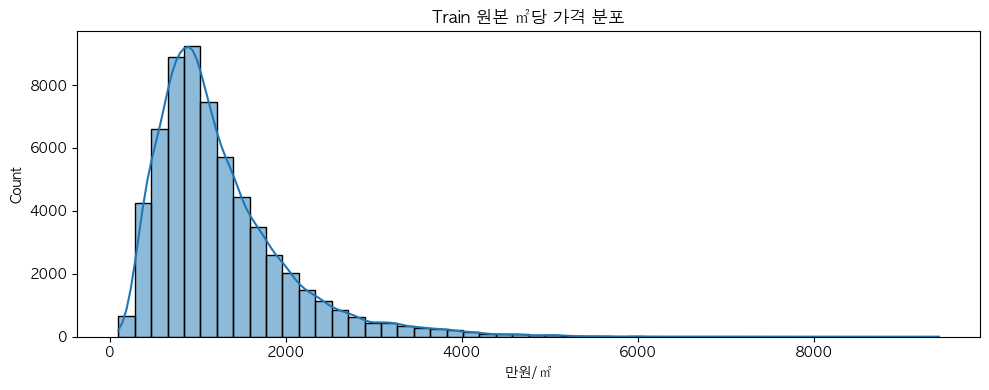

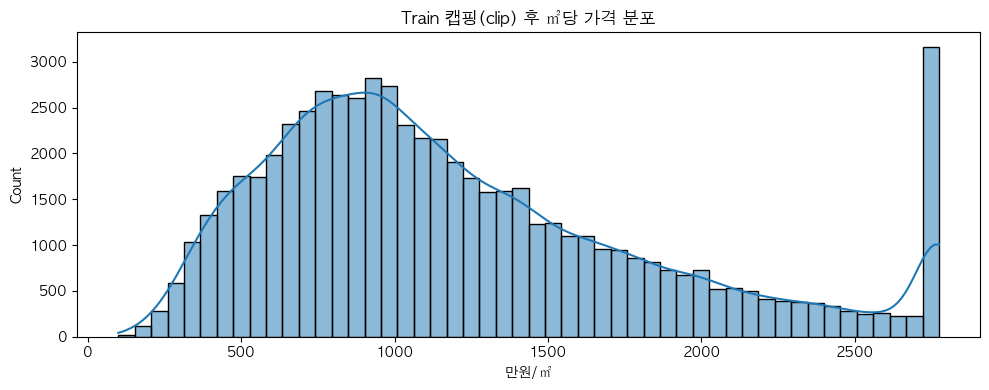

설명(2줄 예시):
- 전처리 기준값(lo/hi)을 test까지 포함해 계산하면, 미리 시험 문제를 본 것처럼 test 정보가 학습에 섞이는 데이터 누수가 생긴다.
- 그래서 SPLIT 후, 기준값은 train에서만 만들고(FIT), test에는 그 기준을 그대로 적용(TRANSFORM)한다.


In [ ]:
# 문제 9) Split -> Fit -> Transform (IQR 캡핑)
from sklearn.model_selection import train_test_split

# 예시: 2024년 데이터만 사용(가볍게)
df_2024 = data_2024.copy()
df_2024["㎡당_가격(만원)"] = df_2024["물건금액(만원)"] / df_2024["건물면적(㎡)"]

# train/test split
train_df, test_df = train_test_split(df_2024, test_size=0.2, random_state=42)

# FIT: train에서만 IQR 경계 계산
q1, q3 = train_df["㎡당_가격(만원)"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
print("IQR lo/hi:", lo, hi)

# TRANSFORM: train/test 모두 동일 경계로 clip 적용
train_df["㎡당_가격_cap"] = train_df["㎡당_가격(만원)"].clip(lo, hi)
test_df["㎡당_가격_cap"] = test_df["㎡당_가격(만원)"].clip(lo, hi)

# 전/후 비교(요약)
compare = pd.DataFrame({
    "원본_mean": [train_df["㎡당_가격(만원)"].mean(), test_df["㎡당_가격(만원)"].mean()],
    "캡핑_mean": [train_df["㎡당_가격_cap"].mean(), test_df["㎡당_가격_cap"].mean()],
    "원본_max": [train_df["㎡당_가격(만원)"].max(), test_df["㎡당_가격(만원)"].max()],
    "캡핑_max": [train_df["㎡당_가격_cap"].max(), test_df["㎡당_가격_cap"].max()],
}, index=["train", "test"])
display(compare)

# 간단 시각화(분포 변화)
plt.figure(figsize=(10,4))
sns.histplot(train_df["㎡당_가격(만원)"], bins=50, kde=True)
plt.title("Train 원본 ㎡당 가격 분포")
plt.xlabel("만원/㎡")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(train_df["㎡당_가격_cap"], bins=50, kde=True)
plt.title("Train 캡핑(clip) 후 ㎡당 가격 분포")
plt.xlabel("만원/㎡")
plt.tight_layout()
plt.show()

print("설명(2줄 예시):")
print("- 전처리 기준값(lo/hi)을 test까지 포함해 계산하면, 미리 시험 문제를 본 것처럼 test 정보가 학습에 섞이는 데이터 누수가 생긴다.")
print("- 그래서 SPLIT 후, 기준값은 train에서만 만들고(FIT), test에는 그 기준을 그대로 적용(TRANSFORM)한다.")


## 문제 10) reshape(melt)로 그래프용 데이터 만들기
- 피벗테이블을 long 형태로 바꾼 뒤, `hue=건물용도`로 barplot

,자치구명,건물용도,평균_㎡당가격(만원)
0,강서구,단독다가구,683.042048
1,송파구,단독다가구,735.654085
2,은평구,단독다가구,773.928983
3,강남구,단독다가구,1684.172252
4,강동구,단독다가구,711.058285


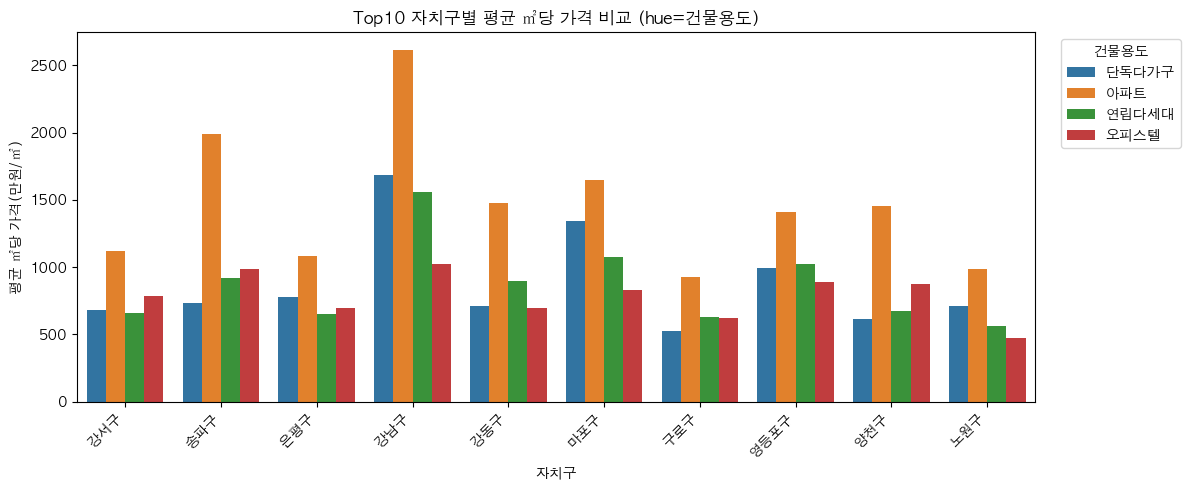

해석 예시: 같은 자치구 안에서도 용도별 평균 ㎡당 가격 차이가 보이며, 자치구 간 비교도 동시에 가능해진다.


In [ ]:
# 문제 10) pivot -> melt -> barplot

pivot_long = (
    pivot_mean.loc[top10_gus]  # Top10 자치구만
    .reset_index()
    .melt(id_vars="자치구명", var_name="건물용도", value_name="평균_㎡당가격(만원)")
)

display(pivot_long.head())

plt.figure(figsize=(12, 5))
sns.barplot(data=pivot_long, x="자치구명", y="평균_㎡당가격(만원)", hue="건물용도", errorbar=None)
plt.title("Top10 자치구별 평균 ㎡당 가격 비교 (hue=건물용도)")
plt.xlabel("자치구")
plt.ylabel("평균 ㎡당 가격(만원/㎡)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="건물용도", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("해석 예시: 같은 자치구 안에서도 용도별 평균 ㎡당 가격 차이가 보이며, 자치구 간 비교도 동시에 가능해진다.")

In [8]:
data_2018 = pd.read_csv('data/2018.csv', encoding='cp949')
data_2019 = pd.read_csv('data/2019.csv', encoding='cp949')
data_2020 = pd.read_csv('data/2020.csv', encoding='cp949')
data_2021 = pd.read_csv('data/2021.csv', encoding='cp949')
data_2022 = pd.read_csv('data/2022.csv', encoding='cp949')
data_2023 = pd.read_csv('data/2023.csv', encoding='cp949')
data_2024 = pd.read_csv('data/2024.csv', encoding='cp949')
dfs = [data_2018,data_2019,data_2020,data_2021,data_2022, data_2023, data_2024]
df = pd.concat(dfs, axis=0, ignore_index=True)

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_5197/197758272.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2019 = pd.read_csv('data/2019.csv', encoding='cp949')
/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_5197/197758272.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2020 = pd.read_csv('data/2020.csv', encoding='cp949')
/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_5197/197758272.py:4: DtypeWarning: Columns (7,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2021 = pd.read_csv('data/2021.csv', encoding='cp949')
/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_5197/197758272.py:7: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2024 = pd.read_csv('data/2024.csv', encoding='cp949')


# 통계 문제 1. IQR 방식의 이상치 처리

IQR 방식으로 물건금액의 이상치를 제거할 때, 이상치로 제거된 행 개수는? *53547*


In [9]:
# IQR 방식의 이상치 제거
q_1 = np.percentile(df['물건금액(만원)'],q=25)
q_3 = np.percentile(df['물건금액(만원)'],q=75)
iqr = q_3 - q_1
q_1, q_3, iqr
lower_whisker = q_1 - 1.5*iqr
upper_whisker = q_3 + 1.5*iqr

In [ ]:
#이상치 개수  : 53547
df.loc[~df['물건금액(만원)'].between(lower_whisker,upper_whisker)].shape

(53547, 21)

In [ ]:
# 주의 이상치를 제거하고 아래 12-16번 문제를 풀이해주세요!
df = df.loc[df['물건금액(만원)'].between(lower_whisker,upper_whisker)]#-- 이상치 제거 

# 통계 문제2. 카이제곱 독립성 검정 & Cramer's V
자치구명과 건물용도가 서로 독립적인지 검정하고, 만약 독립적이라면 Cramer's V를 구한 후 연관성 정도를 해석해라

In [ ]:
# 카이제곱 독립성 검정 & Carmer's V
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['자치구명'],df['건물용도'])
result = chi2_contingency(ct)
result


Chi2ContingencyResult(statistic=np.float64(114200.52040265172), pvalue=np.float64(0.0), dof=72, expected_freq=array([[ 1381.57422962, 10801.42071825,  8896.86926363,  2727.13578851],
       [ 2243.87571564, 17543.06437148, 14449.7982504 ,  4429.26166247],
       [ 1671.09721998, 13064.9687488 , 10761.29908495,  3298.63494627],
       [ 3540.37463881, 27679.34950889, 22798.81140698,  6988.46444532],
       [ 1841.36389741, 14396.147326  , 11857.75871529,  3634.7300613 ],
       [ 1356.04003123, 10601.78930244,  8732.43768989,  2676.73297644],
       [ 2333.30344227, 18242.22803455, 15025.68246661,  4605.78605656],
       [ 1391.90397351, 10882.18070009,  8963.38930937,  2747.52601703],
       [ 2587.60084531, 20230.37545285, 16663.2714578 ,  5107.75224404],
       [ 1861.90732066, 14556.75987416, 11990.05139052,  3675.28141465],
       [ 1718.97384196, 13439.27765343, 11069.60828571,  3393.1402189 ],
       [ 1679.91812488, 13133.9323288 , 10818.10271951,  3316.04682681],
       [ 1946.

12-1. 카이제곱 독립성 검정: 카이제곱 독립성 검정을 했을 때의 p-value를 제시하고, 유의수준 0.05 하에서 귀무가설 기각 여부를 말하라.
- p-value가 0에 근사하므로 두 변수는 서로 독립적이지 않다.

In [ ]:
# Cramer's V
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

cramers_v(ct)

np.float64(0.22090611582352535)

12-2. Cramer's V: 크래머 V 계수를 계산한 결과 (소수점 둘째 자리까지 반올림)
- Cramer's V 가 약 0.22로 약한 상관관계를 보인다

# 통계 문제 3. t-검정

아래의 절차에 따라서 t-검정을 수행하라.
- **밝히고자 하는 가설 : 강서구의 물건금액이 동작구보다 작다.**


- **STEP 1: 가설 설정**  
  - H₀: 귀무가설  
  - H₁: 대립가설  

- **STEP 2: 검정 방법 선택** 
  - 전제조건 성립 확인 : 정규성, 등분산성(독립표본만)
  - 전제조건 성립 확인 후, 검정방법 선택

- **STEP 3: 유의수준 결정**  
  - 보통 **α = 0.05** 사용  

- **STEP 4: 검정통계량 & p-value 계산**  
  - 표본 → 검정통계량 → p-value  

- **STEP 5: 결론**  
  - p ≤ α → 귀무가설 기각  
  - p > α → 귀무가설 채택(유지)


### 13-1. 이 가설에 적절한 검정방법은 무엇인가? 맨 휘트니 u-검정 
### 13-2. p-value 값은? 0.0
### 13-3. 유의수준을 0.01로 설정했을 때, 귀무가설 기각여부?  기각

1. 가설 설정
- 귀무가설 : 강서구의 물건금액이 동작구보다 크거나 같다. 
- 대립가설 : 강서구의 물건금액이 동작구보다 작다. 

2. 검정방법 선택 

In [ ]:
import scipy.stats as stats

In [ ]:
gangseo = df.loc[df['자치구명']=='강서구','물건금액(만원)']
dongjak = df.loc[df['자치구명']=='동작구','물건금액(만원)']

In [ ]:
gangseo_group = gangseo.sample(len(dongjak),random_state=42)
dongjak_group = dongjak.copy()

/Users/hyunjilee/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


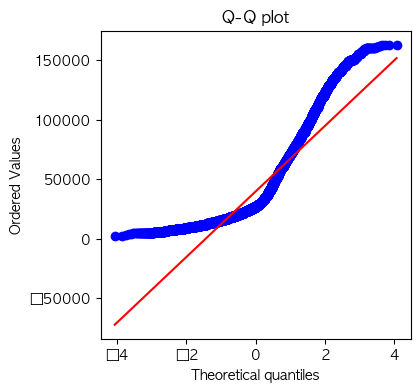

In [ ]:
# 정규성 검정 1. Q-Q plot

plt.figure(figsize=(4,4))
stats.probplot(gangseo_group, plot=plt)
plt.title("Q-Q plot")
plt.show()

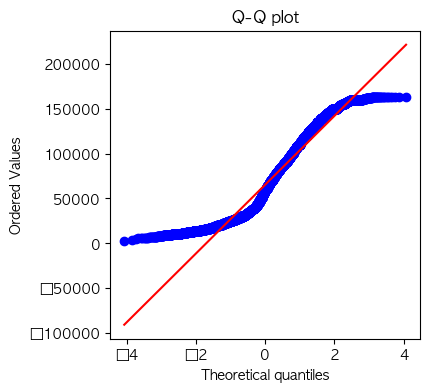

In [ ]:
# 정규성 검정 1. Q-Q plot

plt.figure(figsize=(4,4))
stats.probplot(dongjak_group, plot=plt)
plt.title("Q-Q plot")
plt.show()

In [ ]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(gangseo_group)
# 표본 표준편차
s = np.std(gangseo_group, ddof=1)

stat, p = stats.kstest(gangseo_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.18812973647213377), np.float64(0.0))

In [ ]:
# 정규성 검정 2. Kolmogorov - Sminov

# 표본 평균
sample_mean = np.mean(dongjak_group)
# 표본 표준편차
s = np.std(dongjak_group, ddof=1)

stat, p = stats.kstest(dongjak_group, 'norm', args=(sample_mean, s))

stat, p

(np.float64(0.12545893094654786), np.float64(0.0))

In [ ]:
t_stat, p_value = stats.mannwhitneyu(gangseo_group, dongjak_group, alternative="less")
t_stat, p_value

(np.float64(244557014.0), np.float64(0.0))

p-value가 0 => 유의수준보다 작음 귀무가설 기각 =>강서구의 물건금액 평균이 동작구보다 작다

# 통계 문제 4. ANOVA 검정

다음의 귀무가설에 대해서 가설검정을 하단의 절차에 따라 시행해보자 (힌트 : 일원분산분석, One-way ANOVA)

귀무가설 : 건물용도별로 물건 금액의 차이가 없다. 
 
#### 검정절차
- **STEP 1: 가설 설정**  
  - H₀: 귀무가설  
  - H₁: 대립가설  

- **STEP 2: 검정 방법 선택** 
  - 전제조건 성립 확인 : 정규성, 등분산성, 구형성(반복측정만)  
  - 전제조건 성립 확인 후, 검정방법 선택

- **STEP 3: 유의수준 결정**  
  - 보통 **α = 0.05** 사용  

- **STEP 4: 검정통계량 & p-value 계산**  
  - 표본 → 검정통계량 → p-value  

- **STEP 5: 결론**  
  - p ≤ α → 귀무가설 기각  
  - p > α → 귀무가설 채택(유지)


### 14-1. 이 가설에 적절한 가설검정방법과 사후 검정 방법은 무엇인가? Kruskal-Wallis 검정, Dunn test
### 14-2. p-value 값은? 0.0
### 14-3. 유의수준을 0.05로 설정했을 때, 귀무가설 기각여부? 기각

선택1. 건물용도별로 물건 금액의 차이 유무 검정 (일원분산분석) 

1. 가설설정
- 귀무가설 : 건물용도에 따른 물건 금액 차이가 없다
- 대립가설 : 건물용도에 따른 물건 금액 차이가 있다

2. 검정방법 선택
- 전제조건 확인
    - 정규성 : 표본의 크기가 크므로 중심극한 정리에 의해 정규성 가정 
    - 등분산성 : Levene's test

In [ ]:
apt = df.loc[df['건물용도']=='아파트','물건금액(만원)']
officetel =  df.loc[df['건물용도']=='오피스텔','물건금액(만원)']
multi_housing =  df.loc[df['건물용도']=='연립다세대','물건금액(만원)']
single_housing =  df.loc[df['건물용도']=='단독다가구','물건금액(만원)']

In [ ]:
len(apt), len(officetel), len(multi_housing), len(single_housing)

(353923, 89358, 291517, 45269)

In [ ]:
apt_sample = apt.sample( len(single_housing), random_state=42)
officetel_sample = officetel.sample( len(single_housing), random_state=42)
multi_housing_sample = multi_housing.sample( len(single_housing), random_state=42)
single_housing_sample = single_housing.sample( len(single_housing), random_state=42)

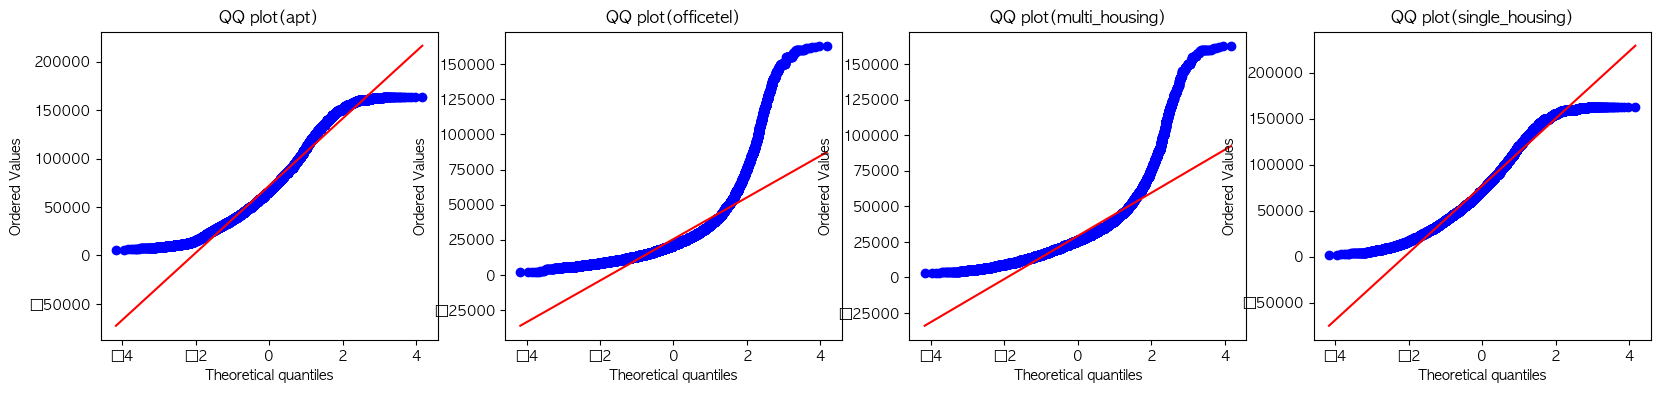

In [ ]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(apt_sample, plot=ax[0])
ax[0].set_title("QQ plot(apt)")
stats.probplot(officetel_sample, plot=ax[1])
ax[1].set_title("QQ plot(officetel)")
stats.probplot(multi_housing_sample, plot=ax[2])
ax[2].set_title("QQ plot(multi_housing)")
stats.probplot(single_housing_sample, plot=ax[3])
ax[3].set_title("QQ plot(single_housing)")
plt.show()

정규성 불만족

kruskal-Wallis 검정 진행

3. 유의 수준 : 0.05

4. 검정통계량, p-value 계산

In [ ]:
stat, p = stats.kruskal(apt_sample, officetel_sample, multi_housing_sample, single_housing_sample)
stat, p

(np.float64(88968.29471236152), np.float64(0.0))

5. 결론
p-value가 0이므로 귀무가설 기각. 건물용도에 따른 물건금액의 차이가 있음을 알 수 있다. 

In [ ]:
df.head()

,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한 개업공인중개사 시군구명
0,2018,11500,강서구,10300,화곡동,1.0,대지,1159.0,0.0,"우장산아이파크,이편한세상",...,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1.0,대지,144.0,0.0,럭키대현,...,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1.0,대지,169.0,32.0,현대,...,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1.0,대지,1380.0,4.0,초산빌라,...,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1.0,대지,189.0,63.0,궁전맨션(189-63),...,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,NaN


# 통계 문제 5: 사후 검정
- 14-3에서 만약 귀무가설이 기각되었다면, 사후검정을 시행해보자. 어떤 건물용도의 쌍에서 서로 금액이 다르다는 결과가 나왔을까? (만약 귀무가설이 채택되었다면, ‘귀무가설 채택’이라고 적기)

In [ ]:
data = pd.DataFrame({
    'value':pd.concat([apt_sample, officetel_sample, multi_housing_sample, single_housing_sample]),
    'group':['apt']* len(single_housing)+['officetel']* len(single_housing)+['multi_housing']* len(single_housing)+['single_housing']* len(single_housing)
})
data

,value,group
468051,80100,apt
825811,110000,apt
712742,24700,apt
6582,43357,apt
213699,81800,apt
...,...,...
149003,13500,single_housing
812690,80000,single_housing
611851,120000,single_housing
11076,100000,single_housing


In [ ]:
import scikit_posthocs as sp
# Dunn 사후검정 
posthoc = sp.posthoc_dunn(data, 
                        val_col="value",
                        group_col="group",
                        p_adjust="holm"
                        )

In [ ]:
posthoc

,apt,multi_housing,officetel,single_housing
apt,1.000000e+00,0.000000e+00,0.000000e+00,3.159721e-45
multi_housing,0.000000e+00,1.000000e+00,5.681751e-224,0.000000e+00
officetel,0.000000e+00,5.681751e-224,1.000000e+00,0.000000e+00
single_housing,3.159721e-45,0.000000e+00,0.000000e+00,1.000000e+00


사후검정 결과를 보았을 때, 모든 조합에서 물건금액의 차이가 나타남을 알 수 있다. (p-value가 모두 0.05미만)

# 통계 문제 6: 상관계수

물건금액과 건물면적의 피어슨 상관계수를 구하라.(소수점 둘째자리까지 반올림)

In [ ]:
df[['물건금액(만원)','건물면적(㎡)']].corr()

,물건금액(만원),건물면적(㎡)
물건금액(만원),1.00000,0.57982
건물면적(㎡),0.57982,1.00000


피어슨 상관계수가 0.58로 중간 정도의 상관관계를 갖는다.

참고) scatter-plot

<Axes: xlabel='물건금액(만원)', ylabel='건물면적(㎡)'>

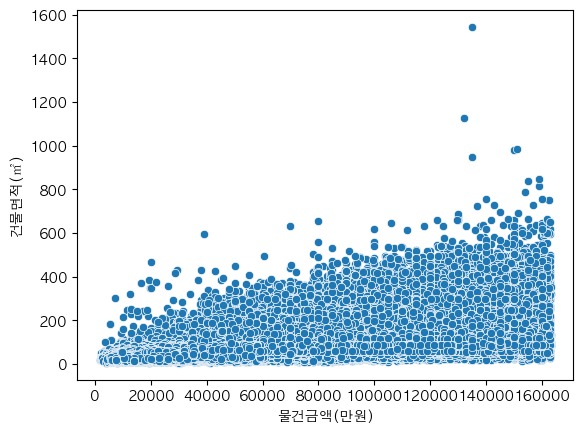

In [ ]:
sns.scatterplot(x='물건금액(만원)',y='건물면적(㎡)',data=df)